In [95]:
import pandas as pd

spotify_dataset = pd.read_csv('spotify_dataset.csv')


In [96]:
spotify_top200 = spotify_dataset.head(200)

In [97]:
# Check for missing values
missing_values = spotify_top200.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0]) 

# Check data types of numeric columns
numeric_columns = spotify_top200.select_dtypes(include=['float64', 'int64']).columns
print("\nData types of numeric columns:")
for col in numeric_columns:
    print(f"{col}: {spotify_top200[col].dtype}")



Missing values in each column:
Series([], dtype: int64)

Data types of numeric columns:
Index: int64
Highest Charting Position: int64
Number of Times Charted: int64


In [98]:
spotify_top200_clean = spotify_top200.dropna()
print(f"Original shape: {spotify_top200.shape}")
print(f"Shape after removing missing values: {spotify_top200_clean.shape}")

Original shape: (200, 23)
Shape after removing missing values: (200, 23)


In [99]:
# Hapus commas di kolom 'Streams' dan ubah menjadi float
spotify_top200_clean['Streams'] = spotify_top200_clean['Streams'].astype(str).str.replace(',', '').astype(float)

In [100]:
# Hapus commas di kolom Artist Followers dan ubah menjadi float
spotify_top200_clean['Artist Followers'] = (spotify_top200_clean['Artist Followers']
										  .astype(str)
										  .str.replace(',', '')  
										  .str.strip()  
										  .str.extract('(\d+)', expand=False)  
										  .astype(float))  

print("Artist Followers data type:", spotify_top200_clean['Artist Followers'].dtype)
print("\nSample of Artist Followers values:")
print(spotify_top200_clean['Artist Followers'].head())



Artist Followers data type: float64

Sample of Artist Followers values:
0     3377762.0
1     2230022.0
2     6266514.0
3    83293380.0
4     5473565.0
Name: Artist Followers, dtype: float64


In [101]:
import pandas as pd

# --- One-Hot Encoding untuk'Genre' 

# 1. Aplikasikan one-hot encoding ke 'Genre' 
#   buat kolom baru dengan tambahan Genre di depannya 'Genre_Pop', 'Genre_Hip Hop'
genre_encoded = pd.get_dummies(spotify_top200_clean['Genre'], prefix='Genre')

# 2. Gabungkan hasil one-hot encoding dengan DataFrame yang sudah dibersihkan
spotify_top200_encoded = pd.concat([spotify_top200_clean, genre_encoded], axis=1)

# 3. Hapus kolom 'Genre' yang asli
spotify_top200_encoded = spotify_top200_encoded.drop('Genre', axis=1)

# 4. Tampilkan DataFrame yang sudah di-encode
print("\nDataFrame after One-Hot Encoding 'Genre':")
print(spotify_top200_encoded.head())
print(f"\nShape after encoding: {spotify_top200_encoded.shape}")

# 5. Tampilkan nama-nama kolom setelah encoding
print("\nColumns after encoding:")
print(spotify_top200_encoded.columns)


DataFrame after One-Hot Encoding 'Genre':
   Index  Highest Charting Position  Number of Times Charted  \
0      1                          1                        8   
1      2                          2                        3   
2      3                          1                       11   
3      4                          3                        5   
4      5                          5                        1   

  Week of Highest Charting                          Song Name     Streams  \
0   2021-07-23--2021-07-30                            Beggin'  48633449.0   
1   2021-07-23--2021-07-30          STAY (with Justin Bieber)  47248719.0   
2   2021-06-25--2021-07-02                           good 4 u  40162559.0   
3   2021-07-02--2021-07-09                         Bad Habits  37799456.0   
4   2021-07-23--2021-07-30  INDUSTRY BABY (feat. Jack Harlow)  33948454.0   

           Artist  Artist Followers                 Song ID Release Date  ...  \
0        Måneskin         33

In [102]:
# Periksa numeric columns
numeric_cols = spotify_top200_clean.select_dtypes(include=['int64', 'float64']).columns
print("Numeric columns:")
for col in numeric_cols:
    print(f"{col}: {spotify_top200_clean[col].dtype}")

Numeric columns:
Index: int64
Highest Charting Position: int64
Number of Times Charted: int64
Streams: float64
Artist Followers: float64


In [112]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb 


# --- Bagian Awal: Pembersihan dan Feature Engineering Genre (dari sebelumnya) ---
spotify_top200_clean['Genre_processed'] = spotify_top200_clean['Genre'].copy()

def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            evaluated_list = ast.literal_eval(x)
            if isinstance(evaluated_list, list):
                return evaluated_list
            else:
                return [evaluated_list]
        except (ValueError, SyntaxError):
            return []
    return x

spotify_top200_clean['Genre_processed'] = spotify_top200_clean['Genre_processed'].apply(safe_literal_eval)

genre_counter = Counter()
for genres in spotify_top200_clean['Genre_processed']:
    if isinstance(genres, list):
        genre_counter.update(genres)

top_n_genres = 10
top_genres = [genre for genre, count in genre_counter.most_common(top_n_genres)]

for genre in top_genres:
    spotify_top200_clean[f'genre_{genre}'] = spotify_top200_clean['Genre_processed'].apply(lambda x: 1 if isinstance(x, list) and genre in x else 0)

# --- 1. Feature Engineering Lebih Lanjut ---

print("Melakukan Feature Engineering...")


# 1.3 Kolom Numerik Asli
all_numeric_cols = spotify_top200_clean.select_dtypes(include=['number']).columns.tolist()

features_to_use = []
for col in all_numeric_cols:
    if col not in [ 'Streams', 'Song ID', 'Artist Followers']:
        features_to_use.append(col)

genre_features_engineered = [col for col in spotify_top200_clean.columns if col.startswith('genre_')]
features_to_use.extend(genre_features_engineered)


features_to_use = list(set(features_to_use))

X = spotify_top200_clean[features_to_use].copy()

y = spotify_top200_clean['Streams']
y_transformed = np.log1p(y)

# --- 2. Tuning Hyperparameter untuk Random Forest Regressor (menggunakan GridSearchCV) ---

print("\n--- Tuning Hyperparameter (Random Forest) ---")
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_features': [0.8, 'sqrt'],
    'min_samples_leaf': [1, 2, 4],
}

grid_search_rf = GridSearchCV(estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
                              param_grid=param_grid_rf,
                              cv=3,
                              scoring='neg_mean_absolute_error',
                              verbose=1,
                              n_jobs=-1)

print("Memulai GridSearchCV untuk Random Forest. Ini mungkin butuh waktu...")
grid_search_rf.fit(X_train, y_train)

print(f"\nHyperparameter terbaik untuk Random Forest: {grid_search_rf.best_params_}")
best_rf_model = grid_search_rf.best_estimator_

y_pred_rf_transformed = best_rf_model.predict(X_test)
y_pred_rf = np.expm1(y_pred_rf_transformed)
y_test_original = np.expm1(y_test)

mae_rf = mean_absolute_error(y_test_original, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf))
r2_rf = r2_score(y_test_original, y_pred_rf)

print("\n--- Evaluasi Model Random Forest Terbaik ---")
print(f"Mean Absolute Error (MAE) RF: {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE) RF: {rmse_rf:.2f}")
print(f"R-squared (R2) RF: {r2_rf:.2f}")

# --- 3. Mencoba Model Lain: LightGBM ---

print("\n--- Melatih dan Mengevaluasi Model LightGBM ---")

lgbm = lgb.LGBMRegressor(objective='regression_l1',
                         n_estimators=500,
                         learning_rate=0.05,
                         num_leaves=31,
                         max_depth=-1,
                         random_state=42,
                         n_jobs=-1)

print("Melatih model LightGBM...")
lgbm.fit(X_train, y_train)
print("Model LightGBM selesai dilatih.")

y_pred_lgbm_transformed = lgbm.predict(X_test)
y_pred_lgbm = np.expm1(y_pred_lgbm_transformed)

mae_lgbm = mean_absolute_error(y_test_original, y_pred_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_test_original, y_pred_lgbm))
r2_lgbm = r2_score(y_test_original, y_pred_lgbm)

print("\n--- Evaluasi Model LightGBM ---")
print(f"Mean Absolute Error (MAE) LGBM: {mae_lgbm:.2f}")
print(f"Root Mean Squared Error (RMSE) LGBM: {rmse_lgbm:.2f}")
print(f"R-squared (R2) LGBM: {r2_lgbm:.2f}")

print("\n--- Perbandingan Performa Model ---")
print(f"Random Forest (Tuned) R2: {r2_rf:.2f}")
print(f"LightGBM R2: {r2_lgbm:.2f}")

print("\nContoh Prediksi vs. Nilai Sebenarnya (LightGBM Top 10):")
predictions_df_lgbm = pd.DataFrame({'Actual Streams': y_test_original, 'Predicted Streams': y_pred_lgbm})
print(predictions_df_lgbm.head(10).round(0))

Melakukan Feature Engineering...

--- Tuning Hyperparameter (Random Forest) ---
Memulai GridSearchCV untuk Random Forest. Ini mungkin butuh waktu...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Hyperparameter terbaik untuk Random Forest: {'max_features': 0.8, 'min_samples_leaf': 2, 'n_estimators': 200}

--- Evaluasi Model Random Forest Terbaik ---
Mean Absolute Error (MAE) RF: 927862.01
Root Mean Squared Error (RMSE) RF: 1299177.13
R-squared (R2) RF: 0.91

--- Melatih dan Mengevaluasi Model LightGBM ---
Melatih model LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 9
[LightGBM] [Info] S

In [106]:

# Create a DataFrame with actual and predicted values from both models, including song names
comparison_df = pd.DataFrame({
    'Song Name': spotify_top200_clean.loc[y_test.index, 'Song Name'],
    'Actual': y_test_original,
    'RF_Prediction': y_pred_rf,
    'LGBM_Prediction': y_pred_lgbm
})
# Sort by absolute error to find best predictions
comparison_df['RF_Error_Percent'] = abs(comparison_df['RF_Prediction'] - comparison_df['Actual']) / comparison_df['Actual'] * 100
comparison_df['LGBM_Error_Percent'] = abs(comparison_df['LGBM_Prediction'] - comparison_df['Actual']) / comparison_df['Actual'] * 100

# Get 10 best predictions (lowest error percentage)
best_predictions = comparison_df.nsmallest(10, 'LGBM_Error_Percent')[['Actual', 'RF_Prediction', 'LGBM_Prediction', 'RF_Error_Percent', 'LGBM_Error_Percent']]

print("\nBest Predictions (Lowest Error Percentage):")
print(best_predictions.round(2))

# Calculate percentage errors
comparison_df['RF_Error_Percent'] = abs(comparison_df['RF_Prediction'] - comparison_df['Actual']) / comparison_df['Actual'] * 100
comparison_df['LGBM_Error_Percent'] = abs(comparison_df['LGBM_Prediction'] - comparison_df['Actual']) / comparison_df['Actual'] * 100

# Sort by error percentage to find worst predictions
worst_predictions = comparison_df.nlargest(10, 'LGBM_Error_Percent')[['Actual', 'RF_Prediction', 'LGBM_Prediction', 'RF_Error_Percent', 'LGBM_Error_Percent']]

# Calculate summary statistics
summary_stats = pd.DataFrame({
    'Metric': ['Mean Actual Streams', 'Mean RF Prediction', 'Mean LGBM Prediction', 
               'Median RF Error %', 'Median LGBM Error %'],
    'Value': [
        comparison_df['Actual'].mean(),
        comparison_df['RF_Prediction'].mean(),
        comparison_df['LGBM_Prediction'].mean(),
        comparison_df['RF_Error_Percent'].median(),
        comparison_df['LGBM_Error_Percent'].median()
    ]
})

# Print results
print("Summary Statistics:")
print(summary_stats.to_string(index=False))
print("\nWorst Predictions (Highest Error Percentage):")
print(worst_predictions.round(2))

# Calculate performance metrics
print("\nPerformance Metrics:")
print(f"Random Forest R² Score: {r2_rf:.4f}")
print(f"LightGBM R² Score: {r2_lgbm:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.2f}")
print(f"LightGBM RMSE: {rmse_lgbm:.2f}")
print(f"Random Forest MAE: {mae_rf:.2f}")
print(f"LightGBM MAE: {mae_lgbm:.2f}")

# Create error distribution plot data
rf_error_dist = pd.Series(comparison_df['RF_Error_Percent'])
lgbm_error_dist = pd.Series(comparison_df['LGBM_Error_Percent'])

print("\nError Distribution Statistics:")
print("\nRandom Forest Error % Distribution:")
print(rf_error_dist.describe().round(2))
print("\nLightGBM Error % Distribution:")
print(lgbm_error_dist.describe().round(2))


Best Predictions (Lowest Error Percentage):
         Actual  RF_Prediction  LGBM_Prediction  RF_Error_Percent  \
150   5647568.0     5454624.83       5609113.55              3.42   
148   5668576.0     6022146.41       5717483.48              6.24   
170   5379704.0     5456637.91       5328590.40              1.43   
15   19480679.0    19583700.45      19780933.03              0.53   
84    7452633.0     7849648.33       7333257.93              5.33   
152   5627257.0     5467119.88       5531503.88              2.85   
124   6152121.0     6569810.52       6033257.44              6.79   
137   5847975.0     5691844.67       5682953.72              2.67   
55    9319465.0     9268324.17       8997208.37              0.55   
165   5434073.0     5667393.55       5665407.31              4.29   

     LGBM_Error_Percent  
150                0.68  
148                0.86  
170                0.95  
15                 1.54  
84                 1.60  
152                1.70  
124          

C:\Users\nicot\AppData\Local\Temp\ipykernel_4684\2244404011.py:32: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[rf_error_percent, lgbm_error_percent],
C:\Users\nicot\AppData\Local\Temp\ipykernel_4684\2244404011.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Random Forest', 'LightGBM'])


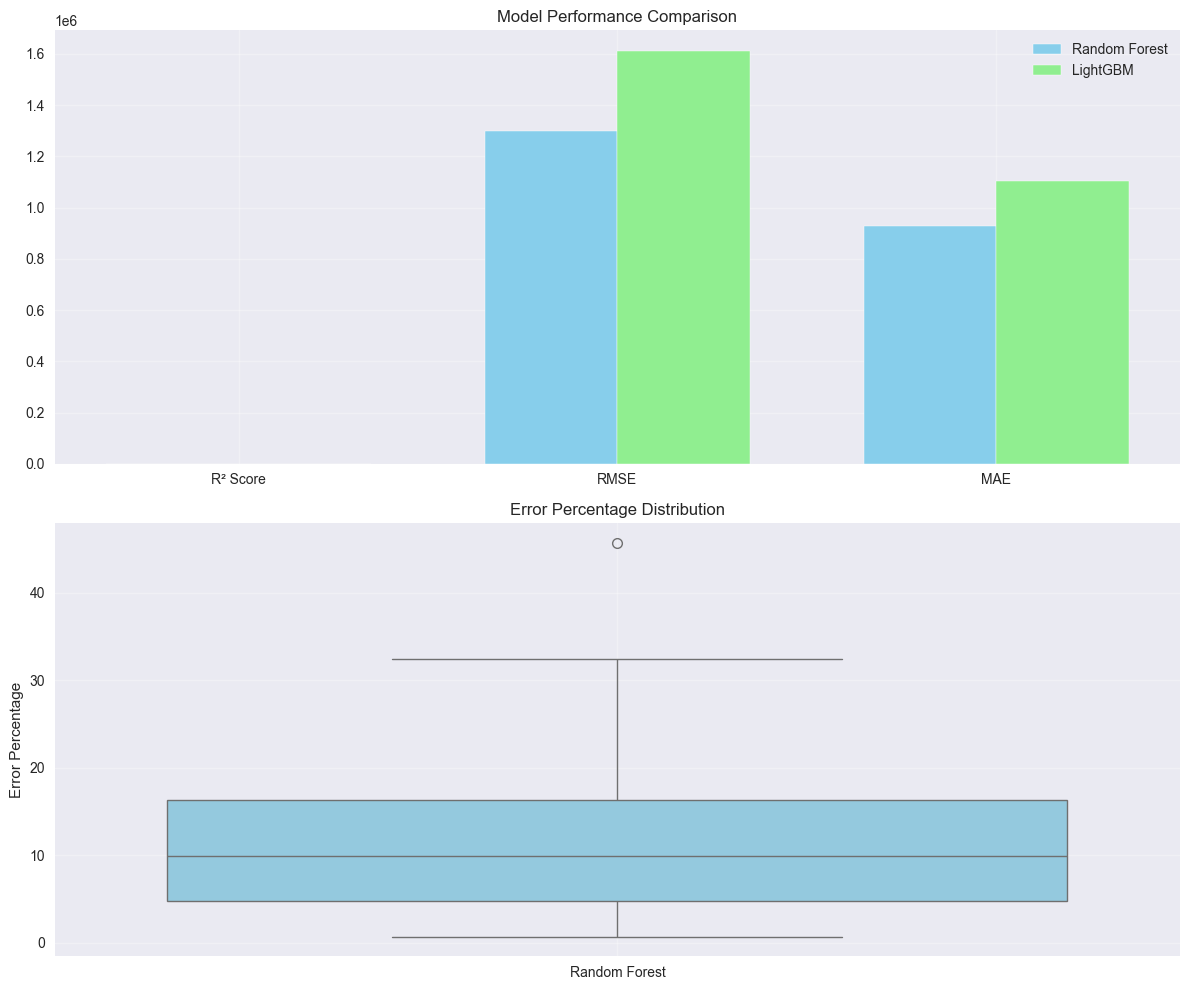

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set a style that's available in matplotlib
plt.style.use('seaborn-v0_8')  # or use 'default' if this doesn't work

# Create figure and axis with larger size
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Model Performance Metrics
metrics = ['R² Score', 'RMSE', 'MAE']
rf_values = [r2_rf, rmse_rf, mae_rf]
lgbm_values = [r2_lgbm, rmse_lgbm, mae_lgbm]

x = np.arange(len(metrics))
width = 0.35

ax1.bar(x - width/2, rf_values, width, label='Random Forest', color='skyblue')
ax1.bar(x + width/2, lgbm_values, width, label='LightGBM', color='lightgreen')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_title('Model Performance Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calculate error percentages
rf_error_percent = np.abs(y_pred_rf - y_test_original) / y_test_original * 100
lgbm_error_percent = np.abs(y_pred_lgbm - y_test_original) / y_test_original * 100

# Plot 2: Error Distribution
sns.boxplot(data=[rf_error_percent, lgbm_error_percent], 
           ax=ax2, palette=['skyblue', 'lightgreen'])
ax2.set_xticklabels(['Random Forest', 'LightGBM'])
ax2.set_title('Error Percentage Distribution')
ax2.set_ylabel('Error Percentage')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

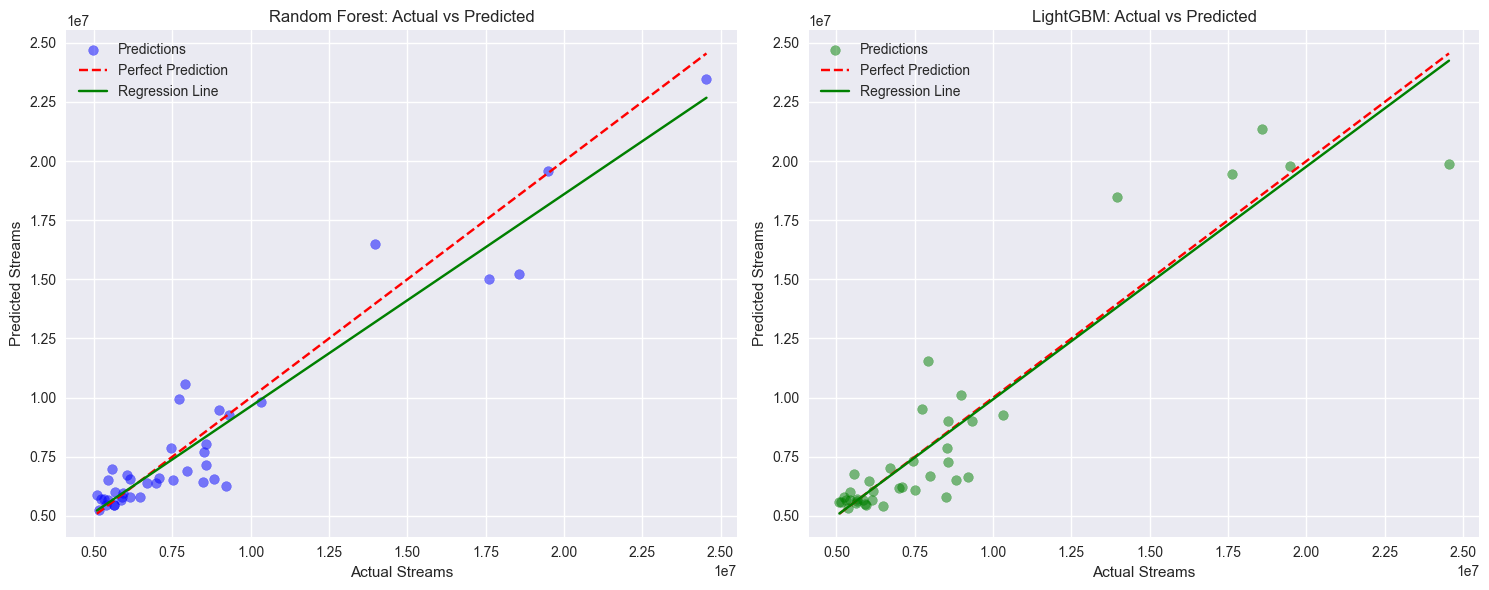

Random Forest Regression Line:
Slope: 0.8968
Intercept: 660671.9898
R² Score: 0.9131

LightGBM Regression Line:
Slope: 0.9838
Intercept: 91264.9104
R² Score: 0.8758


In [119]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
import numpy as np

import matplotlib.pyplot as plt

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot for Random Forest
ax1.scatter(y_test_original, y_pred_rf, alpha=0.5, color='blue', label='Predictions')
ax1.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', label='Perfect Prediction')

# Add regression line for RF
rf_reg = LinearRegression()
rf_reg.fit(y_test_original.values.reshape(-1, 1), y_pred_rf)
rf_line = rf_reg.predict(np.array([y_test_original.min(), y_test_original.max()]).reshape(-1, 1))
ax1.plot([y_test_original.min(), y_test_original.max()], rf_line, 'g-', label='Regression Line')

ax1.set_xlabel('Actual Streams')
ax1.set_ylabel('Predicted Streams')
ax1.set_title('Random Forest: Actual vs Predicted')
ax1.legend()

# Plot for LightGBM
ax2.scatter(y_test_original, y_pred_lgbm, alpha=0.5, color='green', label='Predictions')
ax2.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], 
         'r--', label='Perfect Prediction')

# Add regression line for LGBM
lgbm_reg = LinearRegression()
lgbm_reg.fit(y_test_original.values.reshape(-1, 1), y_pred_lgbm)
lgbm_line = lgbm_reg.predict(np.array([y_test_original.min(), y_test_original.max()]).reshape(-1, 1))
ax2.plot([y_test_original.min(), y_test_original.max()], lgbm_line, 'g-', label='Regression Line')

ax2.set_xlabel('Actual Streams')
ax2.set_ylabel('Predicted Streams')
ax2.set_title('LightGBM: Actual vs Predicted')
ax2.legend()

plt.tight_layout()
plt.show()

# Print regression metrics
print("Random Forest Regression Line:")
print(f"Slope: {rf_reg.coef_[0]:.4f}")
print(f"Intercept: {rf_reg.intercept_:.4f}")
print(f"R² Score: {rf_reg.score(y_test_original.values.reshape(-1, 1), y_pred_rf):.4f}")

print("\nLightGBM Regression Line:")
print(f"Slope: {lgbm_reg.coef_[0]:.4f}")
print(f"Intercept: {lgbm_reg.intercept_:.4f}")
print(f"R² Score: {lgbm_reg.score(y_test_original.values.reshape(-1, 1), y_pred_lgbm):.4f}")